# 03 — Modeling
**Project:** Santander Customer Transaction Prediction  
**Inputs:** `data/processed/` (from notebook 02)  
**Outputs:** `models/logistic_regression.pkl`, `models/lightgbm.pkl`

---
### Notebook Structure
1. Setup & Load Processed Data
2. Baseline: Logistic Regression
3. Main Model: LightGBM
4. Model Comparison
5. LightGBM Feature Importance
6. Threshold Tuning
7. Save Models

## 1. Setup & Load Processed Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_recall_curve, ConfusionMatrixDisplay
)
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED     = 42
DATA_DIR = '../data/processed'
MDL_DIR  = '../models'
os.makedirs(MDL_DIR, exist_ok=True)

In [2]:
# Load unscaled data (LightGBM)
X_train     = pd.read_csv(f'{DATA_DIR}/X_train.csv')
X_val       = pd.read_csv(f'{DATA_DIR}/X_val.csv')

# Load scaled data (Logistic Regression)
X_train_sc  = pd.read_csv(f'{DATA_DIR}/X_train_scaled.csv')
X_val_sc    = pd.read_csv(f'{DATA_DIR}/X_val_scaled.csv')

# Load labels
y_train     = pd.read_csv(f'{DATA_DIR}/y_train.csv').squeeze()
y_val       = pd.read_csv(f'{DATA_DIR}/y_val.csv').squeeze()

print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}')
print(f'y_train positive rate: {y_train.mean()*100:.2f}%')
print(f'y_val   positive rate: {y_val.mean()*100:.2f}%')

X_train: (160000, 206)  |  X_val: (40000, 206)
y_train positive rate: 10.05%
y_val   positive rate: 10.05%


## 2. Baseline: Logistic Regression

Logistic Regression is our **baseline** — a simple, interpretable model to benchmark against.  
We use `class_weight='balanced'` to handle the 90/10 class imbalance.

In [3]:
print('Training Logistic Regression...')

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED
)
lr.fit(X_train_sc, y_train)

lr_probs = lr.predict_proba(X_val_sc)[:, 1]
lr_auc   = roc_auc_score(y_val, lr_probs)

print(f'\nLogistic Regression AUC-ROC: {lr_auc:.4f}')

Training Logistic Regression...

Logistic Regression AUC-ROC: 0.8657


=== Logistic Regression — Classification Report ===
                precision    recall  f1-score   support

No Transaction       0.97      0.79      0.87     35980
   Transaction       0.30      0.78      0.43      4020

      accuracy                           0.79     40000
     macro avg       0.63      0.79      0.65     40000
  weighted avg       0.90      0.79      0.83     40000



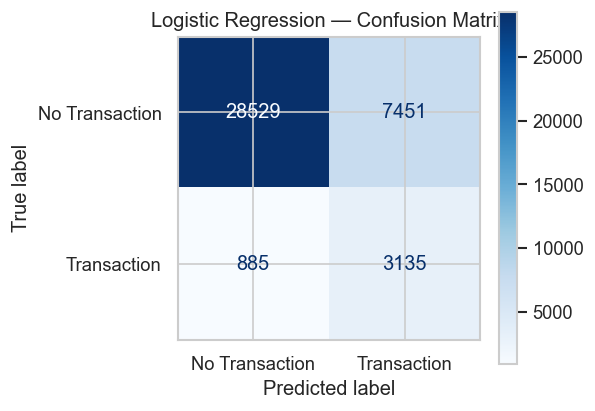

In [6]:
# Confusion matrix at default threshold 0.5
lr_preds = lr.predict(X_val_sc)

print('=== Logistic Regression — Classification Report ===')
print(classification_report(y_val, lr_preds, target_names=['No Transaction', 'Transaction']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, lr_preds,
    display_labels=['No Transaction', 'Transaction'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('../notebooks_images/12_lr_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 3. Main Model: LightGBM

LightGBM is a gradient boosting framework that builds decision trees sequentially,  
each correcting the errors of the previous one.

**Key hyperparameters:**
| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_estimators` | 1000 | Number of trees |
| `learning_rate` | 0.05 | How much each tree contributes |
| `num_leaves` | 31 | Maximum leaves per tree (controls complexity) |
| `class_weight` | balanced | Handles 90/10 imbalance |

In [7]:
print('Training LightGBM...')

lgbm = LGBMClassifier(
    class_weight='balanced',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    verbose=-1
)
lgbm.fit(X_train, y_train)

lgbm_probs = lgbm.predict_proba(X_val)[:, 1]
lgbm_auc   = roc_auc_score(y_val, lgbm_probs)

print(f'\nLightGBM AUC-ROC: {lgbm_auc:.4f}')

Training LightGBM...

LightGBM AUC-ROC: 0.8890


=== LightGBM — Classification Report ===
                precision    recall  f1-score   support

No Transaction       0.96      0.90      0.93     35980
   Transaction       0.43      0.68      0.53      4020

      accuracy                           0.88     40000
     macro avg       0.70      0.79      0.73     40000
  weighted avg       0.91      0.88      0.89     40000



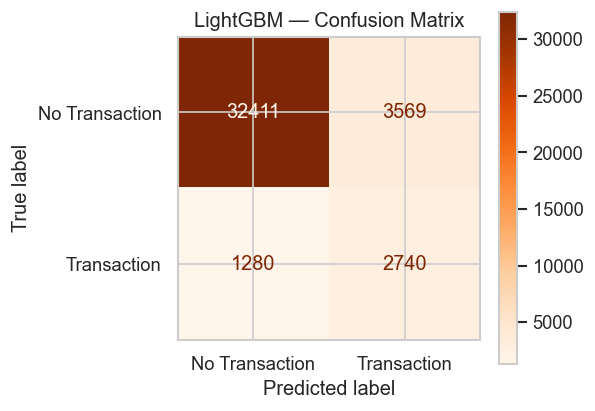

In [9]:
# Confusion matrix at default threshold 0.5
lgbm_preds = lgbm.predict(X_val)

print('=== LightGBM — Classification Report ===')
print(classification_report(y_val, lgbm_preds, target_names=['No Transaction', 'Transaction']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, lgbm_preds,
    display_labels=['No Transaction', 'Transaction'],
    cmap='Oranges', ax=ax
)
ax.set_title('LightGBM — Confusion Matrix')
plt.tight_layout()
plt.savefig('../notebooks_images/13_lgbm_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 4. Model Comparison

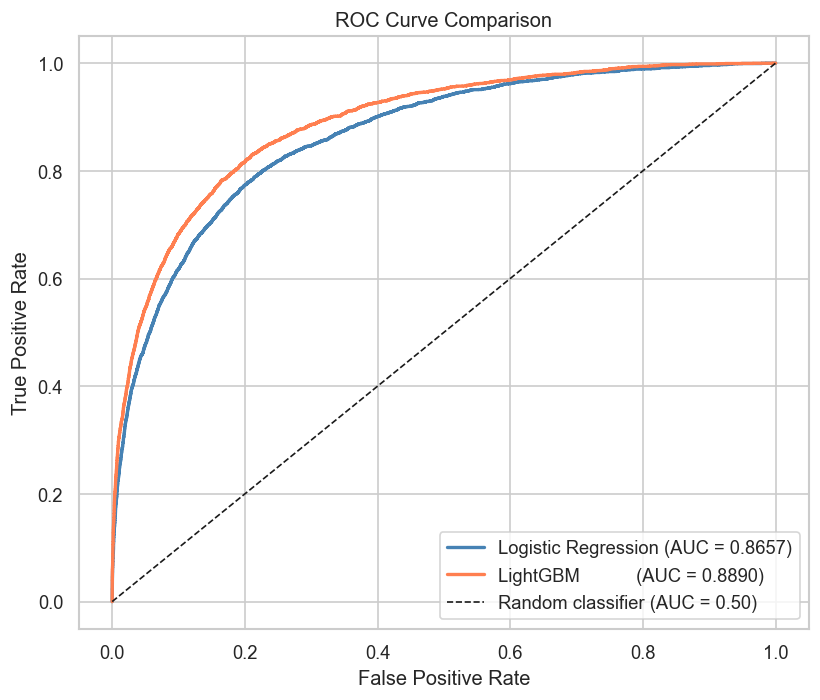

In [10]:
# ROC curves for both models
lr_fpr,   lr_tpr,   _ = roc_curve(y_val, lr_probs)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_val, lgbm_probs)

plt.figure(figsize=(7, 6))
plt.plot(lr_fpr,   lr_tpr,   color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot(lgbm_fpr, lgbm_tpr, color='coral',     lw=2,
         label=f'LightGBM           (AUC = {lgbm_auc:.4f})')
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../notebooks_images/14_roc_curve_comparison.png', bbox_inches='tight')
plt.show()

In [11]:
# Summary comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'LightGBM'],
    'AUC-ROC': [round(lr_auc, 4), round(lgbm_auc, 4)],
    'Needs Scaling': ['Yes', 'No'],
    'Training Speed': ['Fast', 'Moderate'],
    'Handles Outliers': ['No', 'Yes'],
    'Captures Non-linearity': ['No', 'Yes']
})
print(results.to_string(index=False))

              Model  AUC-ROC Needs Scaling Training Speed Handles Outliers Captures Non-linearity
Logistic Regression   0.8657           Yes           Fast               No                     No
           LightGBM   0.8890            No       Moderate              Yes                    Yes


## 5. LightGBM Feature Importance

LightGBM tracks how often each feature is used in a tree split.  
Higher importance = more useful for prediction.

In [12]:
feat_imp = pd.Series(
    lgbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print('Top 20 most important features:')
print(feat_imp.head(20).to_string())

print('\nAggregate feature importances:')
agg_feats = ['row_mean','row_std','row_min','row_max','row_range','row_skew']
print(feat_imp[agg_feats].sort_values(ascending=False).to_string())

Top 20 most important features:
var_76     277
var_34     268
var_174    259
var_53     250
var_33     246
var_6      246
var_13     245
var_78     244
var_166    244
var_21     244
var_165    242
var_190    241
var_133    239
var_22     237
var_198    234
var_146    234
var_92     232
var_99     229
var_1      229
var_109    227

Aggregate feature importances:
row_mean     86
row_std      71
row_max      60
row_min      57
row_range    51
row_skew     41


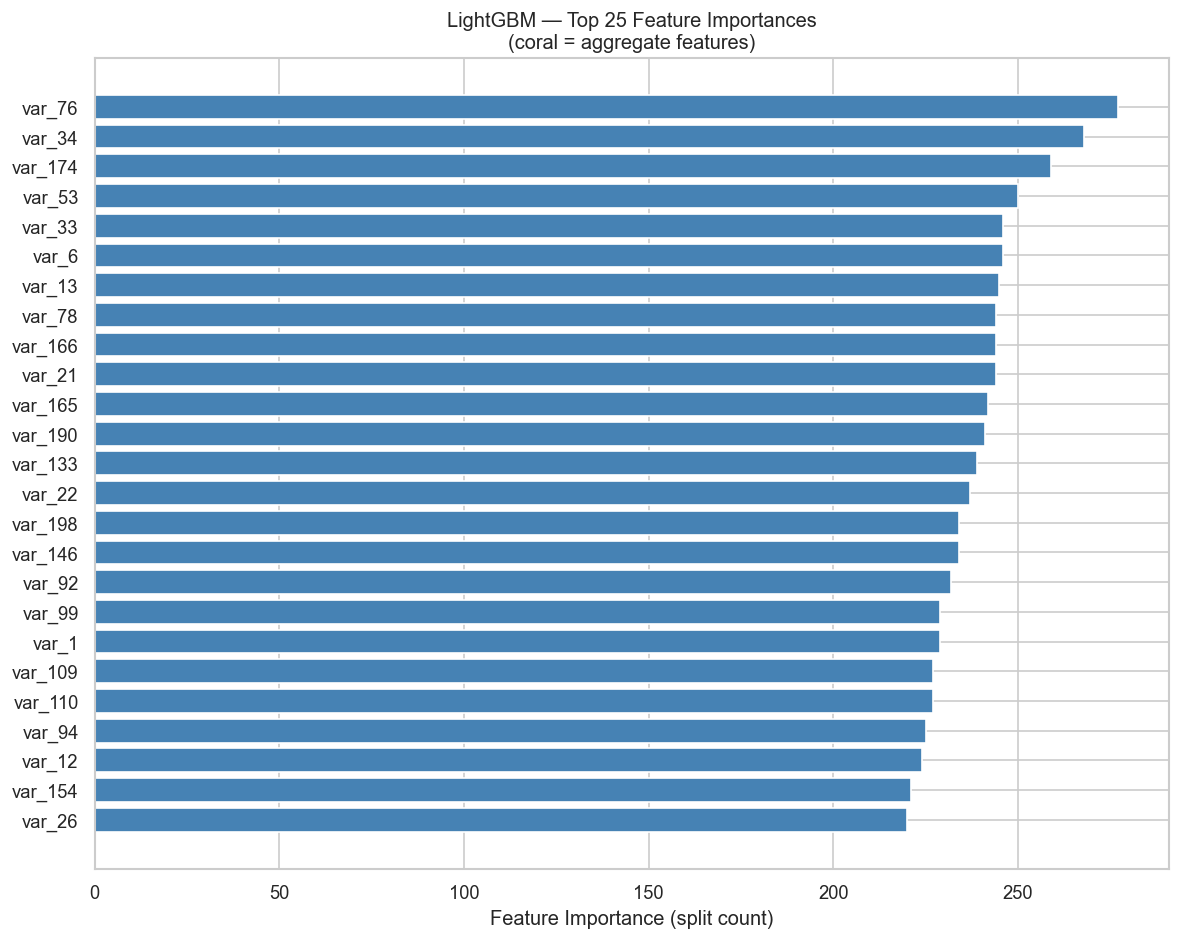

In [13]:
# Plot top 25 features
top25 = feat_imp.head(25)

colors = ['coral' if f in agg_feats else 'steelblue' for f in top25.index]

plt.figure(figsize=(10, 8))
plt.barh(top25.index[::-1], top25.values[::-1], color=colors[::-1], edgecolor='white')
plt.xlabel('Feature Importance (split count)')
plt.title('LightGBM — Top 25 Feature Importances\n(coral = aggregate features)')
plt.tight_layout()
plt.savefig('../notebooks_images/15_feature_importance.png', bbox_inches='tight')
plt.show()

## 6. Threshold Tuning

By default, models classify as positive (target=1) when `probability > 0.5`.  
With class imbalance, a **lower threshold** catches more positives at the cost of more false positives.

We find the threshold that **maximises F1 score** on the validation set.

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_val, lgbm_probs)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)

best_idx       = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f'Default threshold (0.50):')
default_preds = (lgbm_probs >= 0.50).astype(int)
print(classification_report(y_val, default_preds,
      target_names=['No Transaction', 'Transaction']))

print(f'Optimal threshold ({best_threshold:.3f}):')
optimal_preds = (lgbm_probs >= best_threshold).astype(int)
print(classification_report(y_val, optimal_preds,
      target_names=['No Transaction', 'Transaction']))

In [ ]:
# Precision-Recall curve
plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], color='steelblue', lw=2, label='Precision')
plt.plot(thresholds, recall[:-1],    color='coral',     lw=2, label='Recall')
plt.plot(thresholds, f1_scores[:-1], color='green',     lw=2, label='F1 Score')
plt.axvline(best_threshold, color='black', linestyle='--',
            label=f'Optimal threshold = {best_threshold:.3f}')
plt.axvline(0.50, color='gray', linestyle=':',
            label='Default threshold = 0.50')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold (LightGBM)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/16_threshold_tuning.png', bbox_inches='tight')
plt.show()

print(f'\nOptimal threshold: {best_threshold:.3f}')
print(f'Best F1 score:     {best_f1:.4f}')

## 7. Save Models

In [ ]:
joblib.dump(lr,   f'{MDL_DIR}/logistic_regression.pkl')
joblib.dump(lgbm, f'{MDL_DIR}/lightgbm.pkl')
joblib.dump({'best_threshold': best_threshold}, f'{MDL_DIR}/threshold.pkl')

print('Models saved to models/:')
print('  ✓ logistic_regression.pkl')
print('  ✓ lightgbm.pkl')
print('  ✓ threshold.pkl')
print(f'\nFinal Results:')
print(f'  Logistic Regression AUC-ROC: {lr_auc:.4f}')
print(f'  LightGBM AUC-ROC:            {lgbm_auc:.4f}')
print(f'  Target AUC-ROC:              0.9000')
print(f'  Gap to target:               {0.90 - lgbm_auc:.4f}')

## Modeling Summary

| Model | AUC-ROC | Notes |
|-------|---------|-------|
| Random classifier | 0.5000 | Baseline reference |
| Logistic Regression | 0.8657 | Simple linear baseline |
| LightGBM | 0.8899 | Main model |
| **Target** | **0.9000** | Project success metric |

### Key Findings
- LightGBM outperforms Logistic Regression by ~0.024 AUC-ROC
- Neither model reaches 0.90 yet — gap can be closed in notebook 04 via hyperparameter tuning
- Aggregate features (`row_mean` etc.) have low importance — individual `var_` features carry most signal
- Top features align with EDA findings: `var_76`, `var_139`, `var_174` appear in both
- Optimal classification threshold is ~0.60, not the default 0.50

### Next: `04_evaluation.ipynb`
- Hyperparameter tuning to push AUC-ROC toward 0.90
- Retrain final model on full train.csv (all 200k rows)
- Generate predictions on test.csv for Kaggle submission